# Length of Stay and Adoption - Do Longer Stays Make An Animal Less Likely to be Adopted?

---



### 10/30/25

#### Lyn Larson, Desiree Torres, Kanishka Rajesh Harchandani

## Introduction

In this review, we will be searching through the Sonoma Shelter information to find out how the length of stay affects the rate of adoption. Our team will go explore the initial data, clean it, and create visualizations that will support us when trying to answer our main question. Do Longer Stays Make An Animal Less Likely to be Adopted? We will look at data points such as stays between sex, intake type, and breed in order to determine the common factors in longer stay animals vs shorter stay animals.

The Sonoma Shelter dataset provides detailed information about animal intakes and outcomes within the county’s shelter system and is from Sonoma County Animal Services. The data was collected through entries by staff and from the shelters management systems. It represents animal activity from November 2025 and prior. The records contain information about the species, breed, color, size, sex, and age of the animals, along with details of intake/outcome, such as dates, types, and conditions. These variables allow us to  patterns in the animal shelter, including which characteristics are associated with quicker or slower adoptions. By analyzing this dataset, we can gain a better understanding of trends in animal care and adoption behaviors within Sonoma County’s shelter population.

## Initial Data Exploration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Read the data

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/grbruns/cst383/master/sonoma-shelter-13-october-2025.csv')

Checking the number of rows and columns in the dataset.

In [ ]:
df.shape

(31774, 24)

The dataset has 31774 rows and 24 columns. Each row represents one animal's stay at the shelter.

Displaying basic information about the columns, including data types and non-null values.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31774 entries, 0 to 31773
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Name                  23393 non-null  object 
 1   Type                  31774 non-null  object 
 2   Breed                 31774 non-null  object 
 3   Color                 31774 non-null  object 
 4   Sex                   31774 non-null  object 
 5   Size                  31738 non-null  object 
 6   Date Of Birth         24086 non-null  object 
 7   Impound Number        31774 non-null  object 
 8   Kennel Number         31766 non-null  object 
 9   Animal ID             31774 non-null  object 
 10  Intake Date           31774 non-null  object 
 11  Outcome Date          31557 non-null  object 
 12  Days in Shelter       31774 non-null  object 
 13  Intake Type           31774 non-null  object 
 14  Intake Subtype        31774 non-null  object 
 15  Outcome Type       

Most columns are text. Each row is about one animal.

Here’s a quick summary of the numerical columns.

In [ ]:
df.describe().round(1)

,Outcome Zip Code,Count
count,27192.0,31774.0
mean,95042.3,1.0
std,3586.2,0.1
min,1922.0,0.0
25%,95401.0,1.0
50%,95404.0,1.0
75%,95425.0,1.0
max,99701.0,1.0


Only 'Zip Code' and 'Count' are numbers. The count is almost always 1, so each row is for one animal.

Let’s look at the first few rows to see what kind of details are recorded for each animal.

In [ ]:
df.head()

,Name,Type,Breed,Color,Sex,Size,Date Of Birth,Impound Number,Kennel Number,Animal ID,...,Intake Subtype,Outcome Type,Outcome Subtype,Intake Condition,Outcome Condition,Intake Jurisdiction,Outcome Jurisdiction,Outcome Zip Code,Location,Count
0,NaN,DOG,SIBERIAN HUSKY,BLACK/WHITE,Male,MED,NaN,K23-046984,DA21,A422697,...,FLD_STRAY,EUTHANIZE,AGGRESSIVE,UNKNOWN,UNTREATABLE,COUNTY,NaN,NaN,NaN,1
1,NaN,DOG,PIT BULL,GRAY,Female,MED,NaN,K23-046923,DS60,A422443,...,FLD_STRAY,EUTHANIZE,BEH SEVERE,UNKNOWN,UNTREATABLE,SANTA ROSA,NaN,NaN,NaN,1
2,NaN,DOG,GERM SHEPHERD,TAN/BLACK,Female,LARGE,11/11/2021,K23-046766,DS80,A422038,...,FIELD,EUTHANIZE,AGGRESSIVE,UNKNOWN,UNTREATABLE,COUNTY,NaN,NaN,NaN,1
3,BOOMER,DOG,GERM SHEPHERD/PIT BULL,RED,Male,LARGE,01/29/2018,K18-030999,DA17,A381696,...,FLD_ARREST,RETURN TO OWNER,OVER THE COUNTER_ARREST,UNKNOWN,PENDING,COUNTY,SANTA ROSA,95404.0,"(38.451809, -122.692988)",1
4,FAUNA,DOG,GERM SHEPHERD,FAWN,Spayed,SMALL,06/08/2021,K24-047284,DS68,A423685,...,OVER THE COUNTER,RETURN TO OWNER,NaN,UNKNOWN,HEALTHY,SANTA ROSA,NaN,93927.0,"(36.32153, -121.24627)",1


Each row shows one animal, including its type, breed, size, intake and outcome details

Let’s list all the column names in the dataset to get an overview of what we can explore.

In [ ]:
df.columns

Index(['Name', 'Type', 'Breed', 'Color', 'Sex', 'Size', 'Date Of Birth',
       'Impound Number', 'Kennel Number', 'Animal ID', 'Intake Date',
       'Outcome Date', 'Days in Shelter', 'Intake Type', 'Intake Subtype',
       'Outcome Type', 'Outcome Subtype', 'Intake Condition',
       'Outcome Condition', 'Intake Jurisdiction', 'Outcome Jurisdiction',
       'Outcome Zip Code', 'Location', 'Count'],
      dtype='object')

Here's a list of all the column names in the dataset

In [ ]:
list(df.columns)

['Name',
 'Type',
 'Breed',
 'Color',
 'Sex',
 'Size',
 'Date Of Birth',
 'Impound Number',
 'Kennel Number',
 'Animal ID',
 'Intake Date',
 'Outcome Date',
 'Days in Shelter',
 'Intake Type',
 'Intake Subtype',
 'Outcome Type',
 'Outcome Subtype',
 'Intake Condition',
 'Outcome Condition',
 'Intake Jurisdiction',
 'Outcome Jurisdiction',
 'Outcome Zip Code',
 'Location',
 'Count']

There are 24 columns. These include things like animal type, intake reason, shelter stay length, and outcome type.

Counting how many animals belong to each type.

In [ ]:
df['Type'].value_counts()

,count
Type,
DOG,17930
CAT,11173
OTHER,2671


Most animals are dogs or cats. Other types are much fewer.

Now let’s check how animals usually come into the shelter.

In [ ]:
df['Intake Type'].value_counts()

,count
Intake Type,
STRAY,23061
OWNER SURRENDER,3606
CONFISCATE,2920
QUARANTINE,1073
ADOPTION RETURN,507
TRANSFER,432
BORN HERE,124
OS APPT,51


Most animals are brought in as strays. Owner surrenders and confiscations are also common.

Viewing the different outcomes for the animals.

In [ ]:
df['Outcome Type'].value_counts()

,count
Outcome Type,
RETURN TO OWNER,10456
ADOPTION,9078
TRANSFER,6926
EUTHANIZE,4392
DISPOSAL,327
DIED,227
RTOS,78
VET,27
SHELTER,21


Most animals are either returned to their owner, adopted, or transferred. A smaller number are euthanized or have other outcomes.

Let’s make a quick plot showing how many animals there are of each type in the dataset.

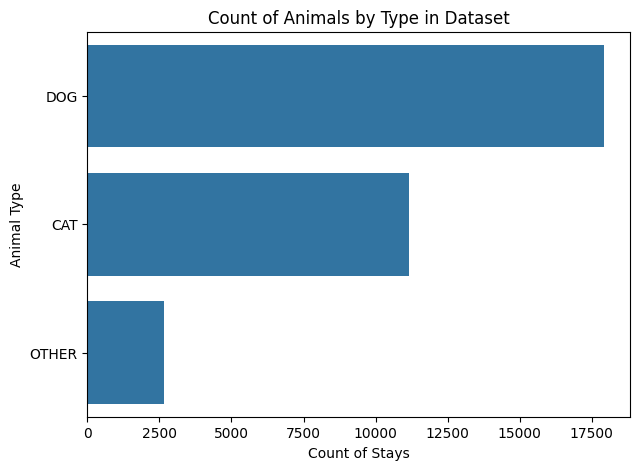

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(y='Type', data=df, order=df['Type'].value_counts().index)
plt.title('Count of Animals by Type in Dataset')
plt.xlabel('Count of Stays')
plt.ylabel('Animal Type')
plt.show();

## Data preprocessing

To make it easier to process the time animals spent in the shelter, we convert the dates to Pandas timestamps.

In [ ]:
df["Intake Date"] = pd.to_datetime(df["Intake Date"])
df["Outcome Date"] = pd.to_datetime(df["Outcome Date"])
df["Date Of Birth"] = pd.to_datetime(df["Date Of Birth"], errors='coerce')

We also clean up by making all the data formated in the same way. In this case, we make it so all strings are uppercase.

In [ ]:
df["Breed"] = df["Breed"].str.upper()
df["Color"] = df["Color"].str.upper()
df["Outcome Type"] = df["Outcome Type"].str.upper()
df["Sex"] = df["Sex"].str.upper()
df["Size"] = df["Size"].str.upper()
df["Intake Type"] = df["Intake Type"].str.upper()
df["Intake Condition"] = df["Intake Condition"].str.upper()
df["Outcome Condition"] = df["Outcome Condition"].str.upper()

Finally, we remove columns that aren't relevant to the question we are exploring.

In [ ]:
df = df.drop(columns=["Kennel Number"])
df = df.drop(columns=["Outcome Condition"])
df = df.drop(columns=["Intake Jurisdiction"])
df = df.drop(columns=["Outcome Jurisdiction"])
df = df.drop(columns=["Outcome Zip Code"])
df = df.drop(columns=["Intake Subtype"])
df = df.drop(columns=["Outcome Subtype"])
df = df.drop(columns=["Location"])
df = df.drop(columns=["Impound Number"])
df.head(10)

,Name,Type,Breed,Color,Sex,Size,Date Of Birth,Animal ID,Intake Date,Outcome Date,Days in Shelter,Intake Type,Outcome Type,Intake Condition,Count
0,NaN,DOG,SIBERIAN HUSKY,BLACK/WHITE,MALE,MED,NaT,A422697,2023-12-04,2024-01-08,35,STRAY,EUTHANIZE,UNKNOWN,1
1,NaN,DOG,PIT BULL,GRAY,FEMALE,MED,NaT,A422443,2023-11-28,2024-01-08,41,STRAY,EUTHANIZE,UNKNOWN,1
2,NaN,DOG,GERM SHEPHERD,TAN/BLACK,FEMALE,LARGE,2021-11-11,A422038,2023-11-11,2024-01-08,58,STRAY,EUTHANIZE,UNKNOWN,1
3,BOOMER,DOG,GERM SHEPHERD/PIT BULL,RED,MALE,LARGE,2018-01-29,A381696,2018-12-26,2018-12-29,3,CONFISCATE,RETURN TO OWNER,UNKNOWN,1
4,FAUNA,DOG,GERM SHEPHERD,FAWN,SPAYED,SMALL,2021-06-08,A423685,2024-01-05,2024-01-08,3,STRAY,RETURN TO OWNER,UNKNOWN,1
5,WILLOW,DOG,SHIH TZU,WHITE,FEMALE,SMALL,2012-04-04,A425655,2024-04-04,2024-04-05,1,STRAY,RETURN TO OWNER,UNKNOWN,1
6,NaN,OTHER,BAT,BROWN,UNKNOWN,SMALL,NaT,A425678,2024-04-05,2024-04-05,0,QUARANTINE,EUTHANIZE,UNKNOWN,1
7,SASHA,DOG,DACHSHUND LH,RED,NEUTERED,TOY,2012-07-13,A299415,2024-03-24,2024-04-05,12,CONFISCATE,RETURN TO OWNER,UNKNOWN,1
8,BOOMER,DOG,GERM SHEPHERD/PIT BULL,RED,MALE,LARGE,2018-01-29,A381696,2018-12-06,2018-12-07,1,STRAY,RETURN TO OWNER,HEALTHY,1
9,ROSIE,DOG,DACHSHUND LH,BROWN/RED,SPAYED,TOY,2012-07-13,A299416,2024-03-24,2024-04-05,12,CONFISCATE,RETURN TO OWNER,UNKNOWN,1


To assist in visualizations, we change the "Days in Shelter" column to be integers instead of strings.

In [ ]:
df['Days in Shelter'] = pd.to_numeric(df['Days in Shelter'], errors='coerce')

## Data Exploration

We need to get a basic idea of how long animals are in the shelter before they are either adopted or have a different outcome. It'll let us know at which point that adoption become more common that other outcomes.

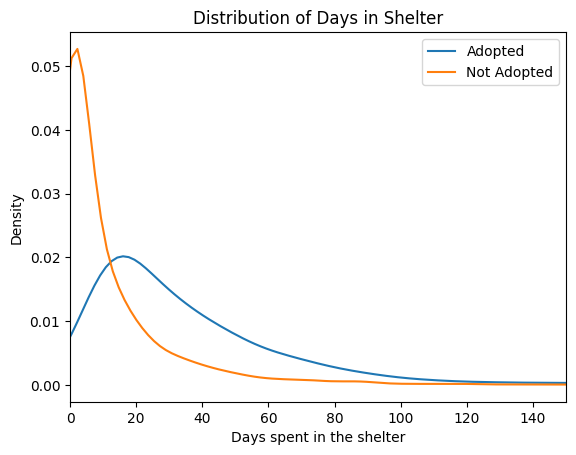

In [ ]:
df['Days in Shelter'][df['Outcome Type']=='ADOPTION'].plot.density(label='Adopted')
df['Days in Shelter'][df['Outcome Type']!='ADOPTION'].plot.density(label='Not Adopted')
plt.title('Distribution of Days in Shelter')
plt.xlabel('Days spent in the shelter')
plt.xlim(0, 150)
plt.legend();

Looks like a lot of animals get adopted after about 20 days in the shelter , but there's a strange spike at the start where almost no adoptions happen.

Let's see how adoption chances change depending on how long an animal stays.

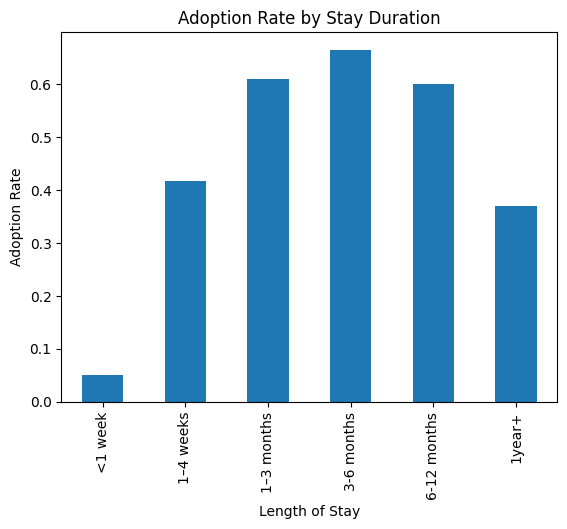

In [ ]:
bins = [0, 7, 30, 90, 182, 365, df['Days in Shelter'].max()]
labels = ['<1 week', '1–4 weeks', '1–3 months', '3-6 months', '6-12 months', '1year+']
df['Length of Stay'] = pd.cut(df['Days in Shelter'], bins=bins, labels=labels, include_lowest=True)

adoption_rate = (df[df['Outcome Type'] == 'ADOPTION']
                 .groupby('Length of Stay', observed=True)
                 .size()
                 / df.groupby('Length of Stay', observed=True).size()
)
adoption_rate.plot.bar(ylabel='Adoption Rate', title='Adoption Rate by Stay Duration');

Once again, this shows how there is very little adoption happening in shorter stays. Adoption seems to happen the most around the 3-6 month mark before going back down.

So what are the results if not adoption?

In [ ]:
(pd.crosstab(df['Length of Stay'], df['Outcome Type'], normalize='index') * 100).round(1)

Outcome Type,ADOPTION,DIED,DISPOSAL,ESCAPED/STOLEN,EUTHANIZE,RETURN TO OWNER,RTOS,SHELTER,TRANSFER,VET
Length of Stay,,,,,,,,,,
<1 week,5.1,0.9,1.7,0.1,13.0,61.6,0.3,0.0,17.2,0.2
1–4 weeks,41.7,0.7,0.6,0.0,17.5,12.9,0.4,0.1,26.1,0.0
1–3 months,60.9,0.3,0.1,0.0,10.8,1.6,0.0,0.1,26.1,0.0
3-6 months,66.5,0.3,0.0,0.0,8.1,3.2,0.0,0.0,22.0,0.0
6-12 months,60.0,1.9,1.4,0.0,9.3,2.8,0.0,0.0,24.7,0.0
1year+,37.0,2.7,0.0,0.0,6.8,4.1,0.0,0.0,49.3,0.0


Let's turn this crosstab into a bar chart to get a better idea.

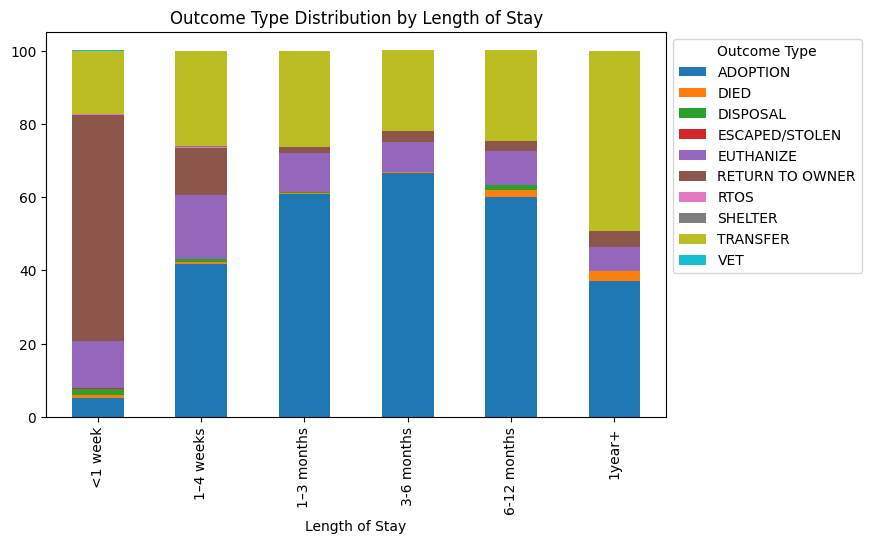

In [ ]:
((pd.crosstab(df['Length of Stay'], df['Outcome Type'], normalize='index') * 100).round(1)).plot.bar(stacked=True, figsize=(8,5))
plt.title('Outcome Type Distribution by Length of Stay')
plt.legend(title='Outcome Type', bbox_to_anchor=(1, 1), loc='upper left');

We finally get to see why there are so little adoptions in that first week of being at the shelter. Majority of the animals are actually returned to their owner rather than going to a new family. If not returned though, they are often euthanized or transferred instead.

It's only after that first week that we start to see adoption as a more common result. Although being transferred, euthanized, or returned are still common outcomes. Once it gets to a month, adoption rates jump up much higher before becoming less common at the 6 month mark. After that, animals are more likely to be transferred when they stay for a full year.

Since there are different categories of the type of animals that end up in the shelter there is a chance that their type affect their outcome. While we aren't focusing on specific animal types, it can still be good to look at and see if anything stands out.

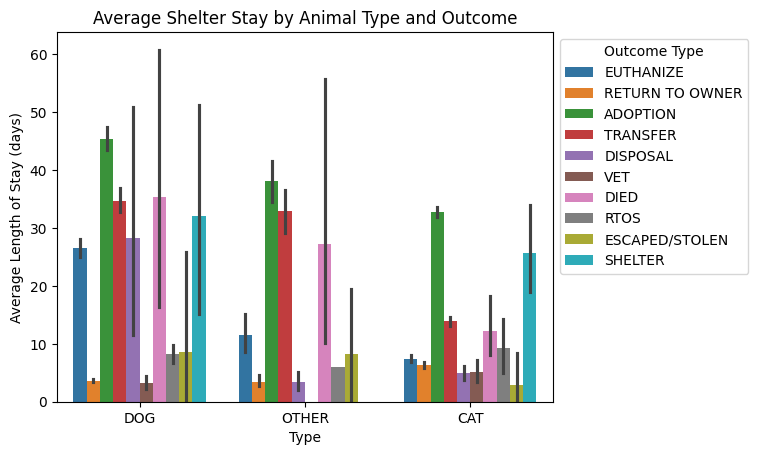

In [ ]:
sns.barplot(x='Type', y='Days in Shelter', hue='Outcome Type', data=df)
plt.title('Average Shelter Stay by Animal Type and Outcome')
plt.ylabel('Average Length of Stay (days)')
plt.legend(title='Outcome Type', bbox_to_anchor=(1, 1), loc='upper left');

We see that dogs and other animals generally stay longer than cats, especially for adoption and transfer outcomes that tend to exceed 40 days. In contrast, animals that are euthanized or returned to their owners typically have much shorter stays, often under 10 days. Cats seem to have more consistent and shorter stays overall, suggesting quicker turnover. Overall, adopted and transferred animals remain the longest, while reclaimed or euthanized animals leave the shelter much sooner.

Let's see if there is any common features in animals that had a long stay but were still adopted.

In [ ]:
adopted = df[df['Outcome Type'] == 'ADOPTION'].copy()

adopted['Long Stay'] = adopted['Days in Shelter'] > adopted['Days in Shelter'].quantile(0.75)

Now we can check if there are any common features. Let's check the type of animal first.

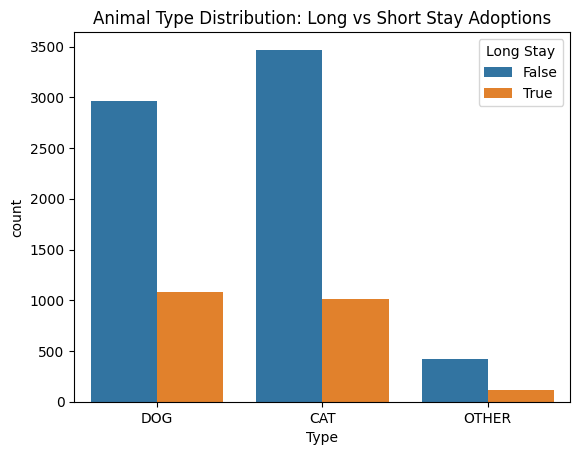

In [ ]:
sns.countplot(data=adopted, x='Type', hue='Long Stay')
plt.title('Animal Type Distribution: Long vs Short Stay Adoptions');

It looks like there are a lot more adoptions for shorter stay animals across the board. One notable detail is that there are more cats that got adopted before staying at the shelter for a long period of time.

What about their sex?

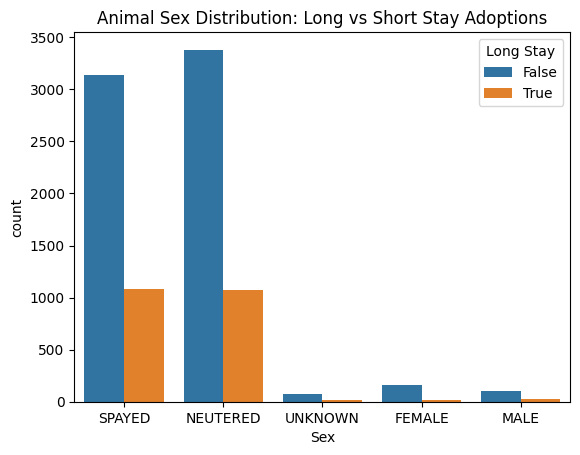

In [ ]:
sns.countplot(data=adopted, x='Sex', hue='Long Stay')
plt.title('Animal Sex Distribution: Long vs Short Stay Adoptions');

Again we see that there are a lot more adoptions that occur for animals who haven't been at the shelter for a long time.

How does intake type fair?

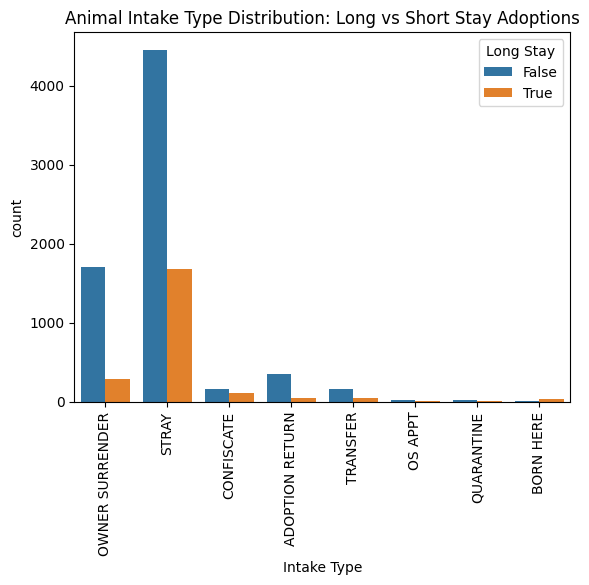

In [ ]:
sns.countplot(data=adopted, x='Intake Type', hue='Long Stay')
plt.title('Animal Intake Type Distribution: Long vs Short Stay Adoptions')
plt.xticks(rotation=90);

There are a lot of animals that come in as a stray so it is not surprising to see that there is a lot of data related to them. This graph may not be very useful as since there is a large difference in the number of data, it is hard to know if being a stray really affects the animal's chances at adoption.

Finally, let's make categories for the age ranges to see if that is a contributing factor.

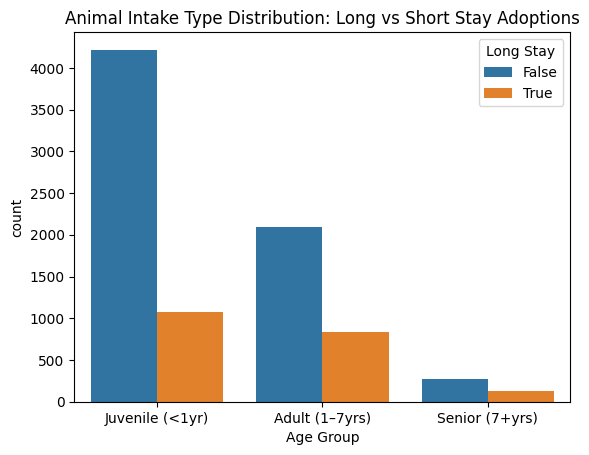

In [ ]:
df['Age at Intake (years)'] = ((df['Intake Date'] - df['Date Of Birth']).dt.days / 365.25).round(2)

adopted['Age Group'] = pd.cut(df['Age at Intake (years)'], bins=[0, 1, 7, 100], labels=['Juvenile (<1yr)', 'Adult (1–7yrs)', 'Senior (7+yrs)'])

sns.countplot(data=adopted, x='Age Group', hue='Long Stay')
plt.title('Animal Intake Type Distribution: Long vs Short Stay Adoptions');

Juveniles have a lot more data like the strays did, though we also see a lot more of them get adopted during a shorter stay.

Lets instead go back to what we did before and look at what outcomes are the most common, but focus on the longer stays instead this time.

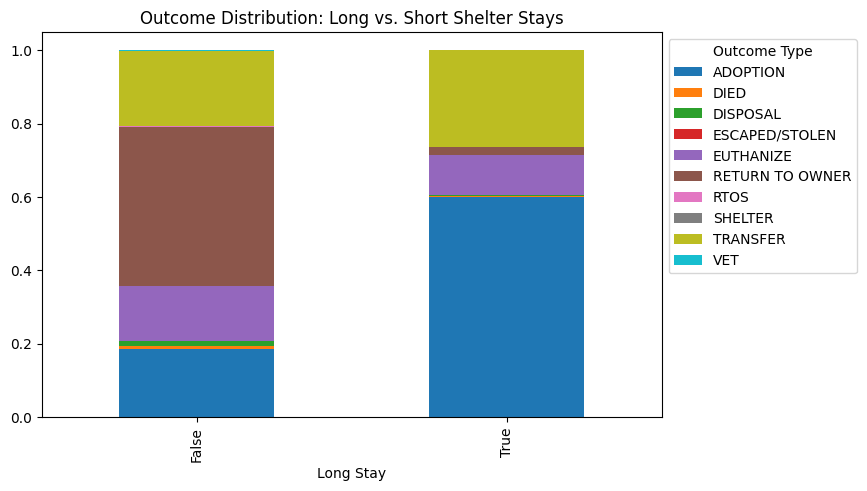

In [ ]:
df['Long Stay'] = df['Days in Shelter'] > df['Days in Shelter'].quantile(0.75)

outcome_by_stay = pd.crosstab(df['Long Stay'], df['Outcome Type'], normalize='index')

outcome_by_stay.plot.bar(stacked=True, figsize=(8,5))
plt.title('Outcome Distribution: Long vs. Short Shelter Stays')
plt.xlabel('Long Stay')
plt.legend(title='Outcome Type', bbox_to_anchor=(1, 1), loc='upper left');

A longer stay actually seems to result in a higher likelihood of being adopted. Shorter stays tend to result in returning to their owner which avoids them having a chance to be adopted in the first place. Euthanizations and transfers are still the next most likely outcome.

Though don't know what happens to the animal once it's transferred and if being moved around from shelter to shelter affect the animals chances. In this dataset, there isn't a whole lot of animals that were transferred to the Sonoma Shelter so we can't investigate that here.

## Conclusions

In this project, we looked at how long animals stay in the shelter and how that affects their chances of getting adopted. The data showed us when each animal came in, how long they stayed and what their outcome was. Some were adopted, some were returned to their owners,and some were transferred.

We saw that animals who are adopted usually stay in the shelter for a while. Animals that leave quickly are often returned to their owners. In some cases, animals are humanely euthanized if they are seriously ill or unsafe to the shelter.  Adoption usually takes time but if an animal stays too long, their chances of getting adopted become very low.

We also noticed that younger animals like kittens and puppies are adopted faster than older ones. Dogs usually stay longer in the shelter than cats, especially when waiting for adoption or transfer. We found that adoption doesn’t usually happen quickly it takes time.

Overall, we learned that animals with very long stays are less likely to be adopted. These animals may need extra support and care.
These patterns could help the shelter figure out which animals need more attention, especially those with longer stays or slower adoption chances.
